# Data Cleaning & Validation

The objective of this notebook is to assess and improve the quality of the dataset before exploratory analysis.

Rather than cleaning data indiscriminately, this notebook evaluates missing values, validates numerical variables, assesses potential outliers, and documents every cleaning decision to ensure the final dataset is reliable, reproducible, and suitable for further analysis.

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:.2f}".format)

water = pd.read_csv("../data/raw/water_potability.csv")

water.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,0
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,0
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,0
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,0
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,0


In [134]:
water.shape

(3276, 10)

In [135]:
water.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


The dataset contains 3,276 observations and 10 variables. All variables are numerical, with the target variable (`Potability`) stored as an integer. Missing values are present in three predictor variables and will be investigated before any cleaning decisions are made.

### 1. Missing Value Assessment

In [136]:
missing = (
    water.isna()
         .sum()
         .to_frame(name="Missing Count")
)

missing["Missing Percentage (%)"] = (
    missing["Missing Count"] /
    len(water) * 100
).round(2)

missing.sort_values(
    by="Missing Count",
    ascending=False
)

,Missing Count,Missing Percentage (%)
Sulfate,781,23.84
ph,491,14.99
Trihalomethanes,162,4.95
Hardness,0,0.00
Chloramines,0,0.00
Solids,0,0.00
Conductivity,0,0.00
Organic_carbon,0,0.00
Turbidity,0,0.00
Potability,0,0.00


> **Observation**
>
>Missing values are concentrated in three variables: ``Sulfate``, `pH`, and `Trihalomethanes`. `Sulfate` has the highest proportion of missing data (23.84%), followed by pH (14.99%) and Trihalomethanes (4.95%). The remaining variables are complete.

#### Visualize Missing Values

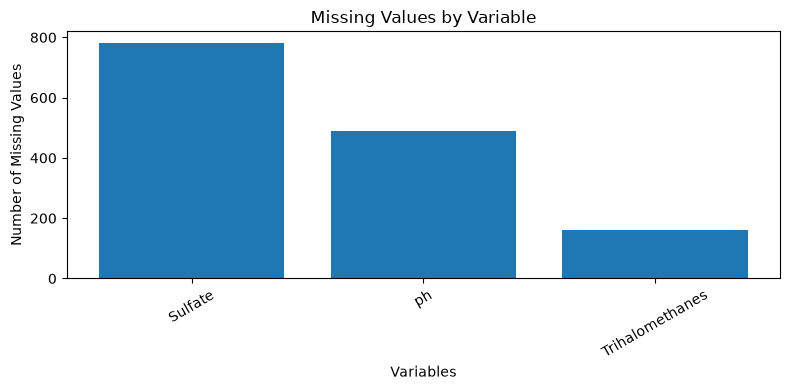

In [137]:
missing = water.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(8,4))

plt.bar(
    missing.index,
    missing.values
)

plt.title("Missing Values by Variable")
plt.xlabel("Variables")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

> **Observation**
>
>The chart confirms that missing values are concentrated in three variables, with ``Sulfate`` accounting for the largest number of missing observations. This indicates that subsequent cleaning efforts should primarily focus on these variables.

#### Rows Affected

In [138]:
rows_with_missing = water.isna().any(axis=1).sum()

rows_percentage = (
    rows_with_missing /
    len(water)
) * 100

round(rows_percentage,2)

np.float64(38.61)

>**Observation**
>
>Although only three variables contain missing values, they affect 1,265 observations (38.61% of the dataset). Removing all incomplete observations would substantially reduce the available data and could introduce bias if the missingness is not completely random.

Although only three variables contain missing values, they affect 1,265 observations, representing approximately 38.61% of the dataset. This indicates that simply removing incomplete rows would substantially reduce the available data and may introduce bias if the missingness is not completely random. For this reason, the pattern of missingness should be investigated before selecting an imputation strategy.

### 2. Investigating the Missingness Pattern

#### Correlation of Missingness

In [139]:
water[["ph", "Sulfate", "Trihalomethanes"]].isna().corr()

,ph,Sulfate,Trihalomethanes
ph,1.00,-0.01,0.01
Sulfate,-0.01,1.00,0.00
Trihalomethanes,0.01,0.00,1.00


>**Observation**
>
>The missingness indicators exhibit near-zero correlations, suggesting that missing values occur largely independently across the three affected variables.

#### Missingness vs Target Variable

In [140]:
water.groupby("Potability")[["Sulfate", "ph", "Trihalomethanes"]].apply(lambda x: x.isna().mean())

,Sulfate,ph,Trihalomethanes
Potability,,,
0,0.24,0.16,0.05
1,0.23,0.14,0.04


>**Observation**
>
>The proportion of missing values is similar for potable and non-potable water samples. There is no strong evidence that missingness is associated with the target variable.

#### Compare Summary Statistics

In [141]:
water[water["Sulfate"].isna()].describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,669.00,781.00,781.00,781.00,0.00,781.00,781.00,741.00,781.00,781.00
mean,7.07,196.87,21848.71,7.13,NaN,428.36,14.15,66.72,3.96,0.38
std,1.62,33.50,8788.19,1.58,NaN,80.99,3.30,16.48,0.77,0.48
min,0.00,103.17,728.75,0.53,NaN,181.48,4.90,0.74,1.64,0.00
25%,6.10,176.79,15736.89,6.15,NaN,368.83,11.95,56.29,3.45,0.00
50%,7.09,196.53,20574.36,7.12,NaN,422.29,14.06,67.10,3.91,0.00
75%,8.05,218.10,27151.31,8.14,NaN,483.82,16.33,77.85,4.48,1.00
max,13.54,323.12,56867.86,12.91,NaN,674.44,28.30,118.36,6.20,1.00


In [142]:
water[water["Sulfate"].notna()].describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2116.00,2495.00,2495.00,2495.00,2495.00,2495.00,2495.00,2373.00,2495.00,2495.00
mean,7.08,196.21,22065.86,7.12,333.78,425.53,14.33,66.29,3.97,0.39
std,1.59,32.69,8763.54,1.58,41.42,80.77,3.31,16.08,0.78,0.49
min,0.23,47.43,320.94,0.35,129.00,201.62,2.20,8.58,1.45,0.00
25%,6.09,176.86,15623.97,6.12,307.70,365.21,12.08,55.70,3.44,0.00
50%,7.03,197.14,21043.63,7.14,333.07,421.63,14.25,66.54,3.97,0.00
75%,8.06,216.42,27372.86,8.11,359.95,481.04,16.62,77.15,4.51,1.00
max,14.00,317.34,61227.20,13.13,481.03,753.34,27.01,124.00,6.74,1.00


>**Observation**
>
>ummary statistics for observations with and without `Sulfate` values are highly comparable. Means, medians, and spreads of the remaining variables show only minor differences, providing no strong indication that observations with missing `Sulfate` values differ systematically from those with observed values.

#### Compare Hardness Distribution

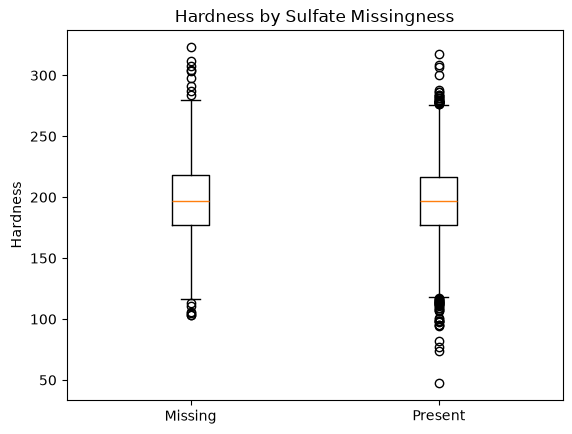

In [143]:
water["Sulfate_missing"] = water["Sulfate"].isna()

plt.boxplot(
    [
        water.loc[
            water["Sulfate_missing"],
            "Hardness"
        ].dropna(),

        water.loc[
            ~water["Sulfate_missing"],
            "Hardness"
        ].dropna()
    ],
    tick_labels=["Missing","Present"]
)

plt.ylabel("Hardness")
plt.title("Hardness by Sulfate Missingness")

plt.show()

>**Observation**
>
>The distribution of Hardness is highly similar for observations with missing and non-missing Sulfate values. Both groups exhibit comparable medians and interquartile ranges, indicating similar central tendency and variability. While the non-missing group contains a few additional low-end outliers, this difference alone is insufficient to conclude that the missingness mechanism depends on Hardness.

#### Missingness Assessment Summary

The exploratory analyses found no strong evidence that the missing values follow a systematic pattern.

The missingness indicators for `pH`, `Sulfate`, and `Trihalomethanes` exhibited near-zero correlations, suggesting that missing values occur independently across the affected variables.

Similarly, the proportion of missing values was comparable between potable and non-potable water samples, indicating no obvious relationship between missingness and the target variable.

Comparisons of descriptive statistics and the distribution of `Hardness` revealed only minor differences between observations with missing and observed `Sulfate` values.

Although these analyses cannot establish the underlying missingness mechanism, they provide no strong evidence that the missing values are systematically associated with the variables examined.

Therefore, the dataset appears suitable for a straightforward imputation strategy, which will be evaluated in the next section.

### 3. Imputation Strategy and Implementation



>Before replacing missing values, it is important to determine whether the mean or the median is the more appropriate imputation statistic. This decision should be based on the characteristics of the data rather than convention. The following analyses examine the distribution, skewness, and presence of outliers in each variable containing missing values.

#### Compare Mean and Median

In [144]:
water[ ["ph", "Sulfate", "Trihalomethanes"] ].agg( ["mean", "median"] ).T

,mean,median
ph,7.08,7.04
Sulfate,333.78,333.07
Trihalomethanes,66.40,66.62


>**Observation**
>
>The mean and median are nearly identical for `ph`, `Sulfate`, and `Trihalomethanes`, indicating that the distributions of these variables are approximately symmetric.

#### Assess Skewness

In [145]:
water[ ["ph", "Sulfate", "Trihalomethanes"] ].skew()

ph                 0.03
Sulfate           -0.04
Trihalomethanes   -0.08
dtype: float64

>**Observation**
>
>All three variables exhibit skewness values close to zero, suggesting negligible skewness and supporting the assumption of approximately symmetric distributions.

#### Assess Outliers

In [146]:
def outlier_summary(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return pd.Series({
        "Outlier Count": len(outliers),
        "Outlier Percentage (%)": round((len(outliers) / len(series)) * 100, 2)
    })

water[ ["ph", "Sulfate", "Trihalomethanes"] ].apply(outlier_summary)

,ph,Sulfate,Trihalomethanes
Outlier Count,46.00,41.00,33.00
Outlier Percentage (%),1.40,1.25,1.01


>**Observation**
>
>Outliers account for less than 2% of observations in each variable. This indicates that extreme values are relatively uncommon and are unlikely to have a substantial influence on the mean.

#### Decision


>The exploratory analyses indicate that ph, Sulfate, and Trihalomethanes are approximately symmetric, exhibit negligible skewness, and contain relatively few outliers. Under these conditions, the mean provides an appropriate estimate of central tendency and is unlikely to be unduly influenced by extreme observations. Therefore, mean imputation was selected to replace missing values in each variable.

##### Apply Mean Imputation

In [147]:
water.fillna( { "ph": water["ph"].mean(), "Sulfate": water["Sulfate"].mean(), "Trihalomethanes": water["Trihalomethanes"].mean() }, inplace=True )

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Sulfate_missing
0,7.08,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,0,False
1,3.72,129.42,18630.06,6.64,333.78,592.89,15.18,56.33,4.50,0,True
2,8.10,224.24,19909.54,9.28,333.78,418.61,16.87,66.42,3.06,0,True
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,0,False
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,0,False
...,...,...,...,...,...,...,...,...,...,...,...
3271,4.67,193.68,47580.99,7.17,359.95,526.42,13.89,66.69,4.44,1,False
3272,7.81,193.55,17329.80,8.06,333.78,392.45,19.90,66.40,2.80,1,True
3273,9.42,175.76,33155.58,7.35,333.78,432.04,11.04,69.85,3.30,1,True
3274,5.13,230.60,11983.87,6.30,333.78,402.88,11.17,77.49,4.71,1,True


##### Validate the Imputation

In [148]:
water.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
Sulfate_missing    0
dtype: int64

>**Observation**
>
>All missing values have been successfully imputed. The dataset now contains complete observations across all variables and is ready for the next stage of analysis.

##### Compare the Dataset Before and After Imputation

In [149]:
comparison = pd.DataFrame({ "Before": [ 491, 781, 162 ], "After": water[ ["ph", "Sulfate", "Trihalomethanes"] ].isna().sum().values }, index=[ "ph", "Sulfate", "Trihalomethanes" ])

comparison

,Before,After
ph,491,0
Sulfate,781,0
Trihalomethanes,162,0


>**Observation**
>
>The comparison confirms that all previously missing values have been replaced successfully. No additional variables were affected during the cleaning process.

>**Section Summary*
>
>This section evaluated the suitability of different imputation methods using descriptive statistics, skewness, and outlier analysis. The evidence showed that ph, Sulfate, and Trihalomethanes are approximately symmetric and contain relatively few outliers. Based on these findings, mean imputation was selected and applied to all missing values. The resulting dataset contains no missing observations and is ready for data validation and exploratory analysis.

### 4. Data Validation


>Following the imputation process, the dataset should be validated to ensure that the cleaning operations were successful and that the overall structure and integrity of the data have been preserved.

#### Verify Data Types


In [150]:
water.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
 10  Sulfate_missing  3276 non-null   bool   
dtypes: bool(1), float64(9), int64(1)
memory usage: 259.3 KB


>**Observation**
>
>All variables retain appropriate numerical data types after imputation. Predictor variables remain stored as floating-point values, while the target variable (`Potability`) remains an integer.

#### Check for Missing Values

In [151]:
water.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
Sulfate_missing    0
dtype: int64

>**Observation**
>
>The dataset contains no missing values, confirming that the imputation process was successfully completed.

#### Check for Duplicate Records

In [152]:
water.duplicated().sum()

np.int64(0)

>**Observation**
>
>No duplicate observations were identified after the cleaning process, indicating that data integrity has been preserved.

In [153]:
water.shape

(3276, 11)

#### Remove Temporary Analysis Columns

>During the investigation of missingness patterns, a temporary helper column (`Sulfate_missing`) was created. Since this variable was used solely for exploratory purposes, it should be removed before exporting the cleaned dataset.

In [154]:
water.drop(columns="Sulfate_missing", inplace=True)

#### Verify Dataset Structure


In [155]:
water.shape

(3276, 10)

In [156]:
water.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


>**Observation**
>
>The temporary helper column has been removed successfully. The cleaned dataset now contains the original 10 variables and 3,276 observations, confirming that the cleaning process preserved the intended dataset structure.

>*Section Summary*
>
>The validation process confirms that the cleaning workflow was completed successfully. The dataset contains no missing values, no duplicate observations, appropriate data types, and the original dataset structure has been preserved. The data are now ready for exploratory analysis.

### Export the Clean Dataset

>The cleaned dataset should be saved separately from the raw dataset to preserve the original data and establish a reproducible analytical workflow.

#### Create the Output Directory

In [157]:
from pathlib import Path

Path("../data/processed").mkdir( parents=True, exist_ok=True )

#### Export the Clean Dataset

In [158]:
water.to_csv( "../data/processed/water_clean.csv", index=False )

#### Confirm the Export

In [159]:
Path("../data/processed/water_clean.csv").exists()

True

>**Observation**
>
>The cleaned dataset has been exported successfully to the processed directory. This file will serve as the input dataset for the exploratory data analysis notebook, ensuring that all subsequent analyses are performed on the validated and cleaned data.

### Sprint 3 Summary

This notebook prepared the raw dataset for exploratory analysis through a structured and evidence-based data cleaning workflow.

The following tasks were completed:

* Assessed the extent and distribution of missing values.
* Investigated whether missingness followed a systematic pattern.
* Evaluated appropriate imputation methods using distributional characteristics, skewness, and outlier analysis.
* Applied mean imputation based on empirical evidence.
* Validated the cleaned dataset by verifying missing values, duplicate records, data types, and dataset structure.
* Exported a processed dataset for use in subsequent analyses.

The dataset is now complete, internally consistent, and ready for exploratory data analysis. The next stage of the project will focus on exploring relationships among variables, identifying patterns, and generating insights into the factors associated with water potability.